# FIT5196 作业2 - Task 1：数据清洗与初步分析

**小组：032**

**日期：2025年10月**

---

## 目录
1. 项目背景与目标
2. 数据理解与初步探索（EDA）
3. 业务规则校验与错误检测
4. 缺失值分析与填补
5. 异常值检测与处理
6. 业务修正与数据标准化
7. 结果验证与输出保存

---

## 1. 项目背景与目标

本节简要介绍DigiCO在线电子商店数据清洗任务的背景、目标和主要分析流程。

In [1]:
# 导入本次数据清洗分析所需的主要库
import pandas as pd  # 数据处理
import numpy as np  # 数值计算
import matplotlib.pyplot as plt  # 可视化
import seaborn as sns  # 可视化
from sklearn.impute import SimpleImputer, KNNImputer  # 缺失值填补
from math import radians, cos, sin, asin, sqrt  # 地理距离计算
import dateutil.parser as parser  # 日期解析
import warnings
warnings.filterwarnings('ignore')

# 初始化情感分析器（nltk VADER）
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# nltk.download('vader_lexicon')
analyzer = SentimentIntensityAnalyzer()

print('Libraries imported successfully.')

# Tips:
# - pandas和numpy是数据科学的基础库，建议熟练掌握。
# - matplotlib和seaborn用于数据可视化，能帮助理解数据分布和关系。
# - sklearn提供了丰富的数据预处理工具。
# - warnings.filterwarnings('ignore')可屏蔽不影响结果的警告信息。

Libraries imported successfully.


In [2]:

# 定义输入文件路径
input_files = {
    'dirty': 'Group_032_dirty_data.csv',
    'missing': 'Group_032_missing_data.csv',
    'outlier': 'Group_032_outlier_data.csv',
    'warehouses': 'warehouses.csv'
}

# 加载数据集
# Tips: 文件名要和实际文件保持一致，否则会报错

dirty_data = pd.read_csv(input_files['dirty'])
missing_data = pd.read_csv(input_files['missing'])
outlier_data = pd.read_csv(input_files['outlier'])
warehouses = pd.read_csv(input_files['warehouses'])

print('Datasets loaded:')
for k, v in input_files.items():
    print(f"  {k}: {v}")

# 思路：
# 1. 先加载所有后续分析需要的数据。
# 2. 每一步都建议print输出，便于检查数据是否加载正确。

Datasets loaded:
  dirty: Group_032_dirty_data.csv
  missing: Group_032_missing_data.csv
  outlier: Group_032_outlier_data.csv
  warehouses: warehouses.csv


## 2. 数据理解与EDA（探索性数据分析）

### 2.1 业务背景理解

**DigiCO 在线电子商店：**
- 墨尔本本地的纯线上电子产品零售商
- 在墨尔本设有3个战略仓库
- 主营10种品牌电子产品
- 季节性业务规则影响运费定价
- 通过客户评论和情感分析追踪客户满意度

In [3]:
dirty_data

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer
0,ORD353729,ID0580158995,2019-02-12,Thompson,"[('pearTV', 2), ('Thunder line', 2)]",16980,81.58,-37.800007,144.937131,0,17061.58,Summer,False,1.6589,five stars good price,True
1,ORD214948,ID0452381158,2019-11-20,Thompson,"[('iAssist Line', 2), ('Thunder line', 2), ('L...",12490,67.40,-37.825010,144.949517,5,11932.90,Spring,True,1.3901,most certainly would come with a bad battery b...,False
2,ORD099836,ID2759826598,2019-01-18,Nickolson,"[('Universe Note', 2), ('iAssist Line', 1), ('...",17895,96.85,-37.810411,144.961597,15,15307.60,Summer,True,1.1486,NaN,True
3,ORD468917,ID0127638288,2019-06-02,Thompson,"[('iAssist Line', 1), ('Thunder line', 2), ('U...",10035,74.52,-37.809585,144.946730,15,8604.27,Winter,True,0.3450,beautiful phone that feels great in your hand ...,True
4,ORD077630,ID0581718875,2019-03-12,Thompson,"[('Alcon 10', 1), ('Toshika 750', 2), ('pearTV...",18400,66.66,-37.805141,144.934469,25,13866.66,Autumn,False,1.3896,nice phone the phone came early but it was cle...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD137345,ID3148693051,2019-09-03,Nickolson,"[('iAssist Line', 2), ('Olivia x460', 2), ('Un...",17720,61.14,-37.812028,144.972213,15,15123.14,Spring,False,0.7676,your getting cheated out of your money!! once ...,False
496,ORD212007,ID6202471436,2019-01-14,Nickolson,"[('iAssist Line', 2), ('pearTV', 1), ('Lucent ...",12850,74.22,-37.822411,144.981105,5,12281.72,Summer,False,1.1012,five stars i love it. excellent!!,False
497,ORD414145,ID0277118918,2019-12-26,Thompson,"[('iAssist Line', 1), ('Thunder line', 1), ('T...",8725,87.96,-37.822323,144.933451,15,7504.21,Summer,True,1.3923,locked phone only verizon can take it and i do...,False
498,ORD105709,ID4884440917,2019-01-30,Thompson,"[('pearTV', 2), ('Lucent 330S', 2), ('Alcon 10...",37300,87.58,-37.799786,144.934886,0,9265.83,Summer,True,1.7905,came broken the sim card holder came broke. ca...,False


In [4]:
# 查看 dirty_data 的基本信息
print("数据维度 (shape):", dirty_data.shape)
print("\n字段名 (columns):", dirty_data.columns.tolist())
print("\n数据类型 (dtypes):\n", dirty_data.dtypes)
print("\n缺失值统计 (missing values):\n", dirty_data.isnull().sum())
print("\n每列唯一值个数 (nunique):\n", dirty_data.nunique())
print("\n前5行数据预览 (head):\n", dirty_data.head())

数据维度 (shape): (500, 16)

字段名 (columns): ['order_id', 'customer_id', 'date', 'nearest_warehouse', 'shopping_cart', 'order_price', 'delivery_charges', 'customer_lat', 'customer_long', 'coupon_discount', 'order_total', 'season', 'is_expedited_delivery', 'distance_to_nearest_warehouse', 'latest_customer_review', 'is_happy_customer']

数据类型 (dtypes):
 order_id                          object
customer_id                       object
date                              object
nearest_warehouse                 object
shopping_cart                     object
order_price                        int64
delivery_charges                 float64
customer_lat                     float64
customer_long                    float64
coupon_discount                    int64
order_total                      float64
season                            object
is_expedited_delivery               bool
distance_to_nearest_warehouse    float64
latest_customer_review            object
is_happy_customer                   b

In [5]:
print('主要数值特征描述:')
print(dirty_data.describe())

主要数值特征描述:
        order_price  delivery_charges  customer_lat  customer_long  \
count    500.000000        500.000000    500.000000     500.000000   
mean   13934.990000         76.974500    -27.942350     135.095259   
std     8347.277102         14.610351     41.351359      41.352954   
min      730.000000         45.230000    -37.827327     -37.827773   
25%     7521.250000         66.475000    -37.818685     144.948690   
50%    12197.500000         76.265000    -37.811936     144.961026   
75%    19000.000000         84.257500    -37.805031     144.977129   
max    39880.000000        166.920000    145.008953     145.020535   

       coupon_discount   order_total  distance_to_nearest_warehouse  
count       500.000000    500.000000                     500.000000  
mean         11.080000  12419.300640                       1.132155  
std           8.659305   7328.828608                       0.700616  
min           0.000000    840.200000                       0.074000  
25%      

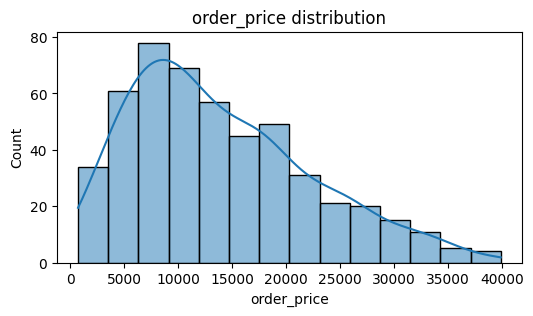

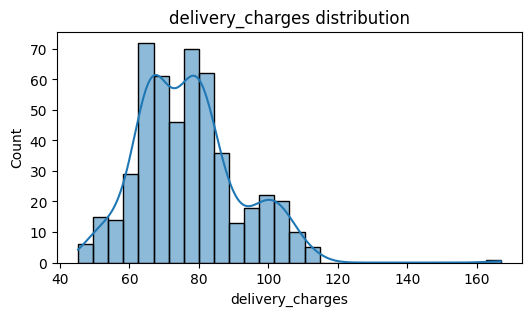

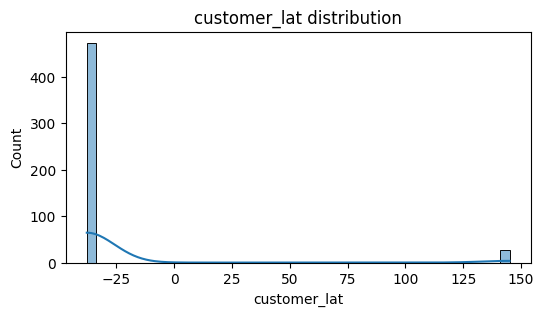

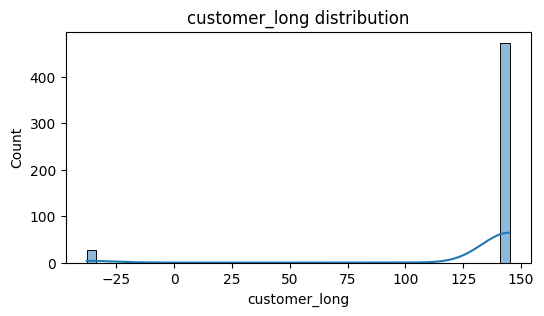

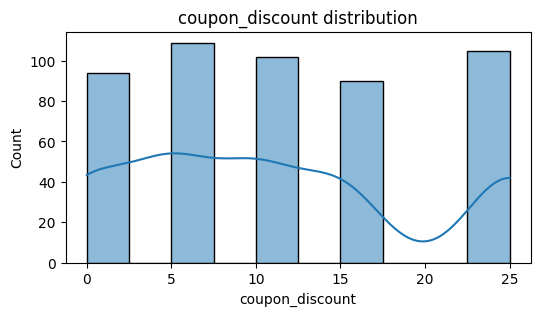

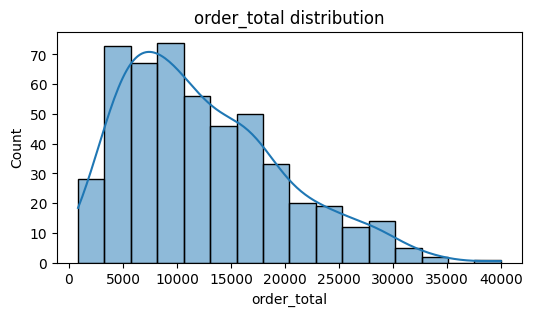

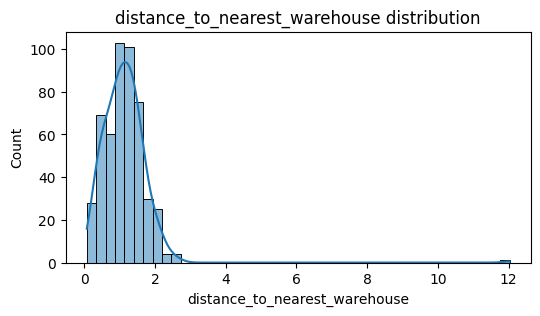

In [6]:
# 可视化主要数值特征的分布
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = dirty_data.select_dtypes(include=[np.number]).columns
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(dirty_data[col].dropna(), kde=True)
    plt.title(f'{col} distribution')
    plt.show()

1. **经纬度异常**  
   - `customer_lat` 和 `customer_long` 的最大值远超正常范围（最大值分别为145.01和145.02，最小值为-37.82和-37.82）。  
   - 墨尔本的经纬度大致范围应为纬度 -38 ~ -37， 经度 144 ~ 145。出现145的纬度和负数的经度明显异常，说明有坐标错误。

2. **距离异常**  
   - `distance_to_nearest_warehouse` 最大值为12.03，最小值为0.07，绝大多数数据分布合理，但需结合坐标进一步核查。

3. **价格与总价**  
   - `order_price`、`order_total`、`delivery_charges`的最大最小值和均值分布合理，但需结合业务规则进一步校验（如order_total是否等于order_price减折扣加运费）。

4. **优惠券折扣**  
   - `coupon_discount` 最大25%，最小0%，分布合理。

5. **数据完整性**  
   - 每个字段都是500条数据，无缺失。

---

**初步结论：**  
- 存在明显的经纬度异常，需要重点检查和修正。
- 其他数值分布基本合理，但还需结合业务逻辑做进一步一致性校验（如总价、距离等）。
- 建议后续对经纬度、距离、总价等字段做详细的业务规则校验和异常修正。


### 2.2 数据结构详细分析

本节将详细检查每个数据集的结构和内容，帮助理解后续清洗和分析的基础。

- **字段数量与类型**：所有主数据集均包含16个字段，涵盖订单、客户、商品、仓库、价格、运费、坐标、评论等关键信息。字段类型包括字符串、数值、布尔值等，便于后续处理。
- **数据规模**：每个数据集包含500行，结构一致，便于批量处理和对比分析。
- **字段说明**：
    - `order_id`、`customer_id`：唯一标识，无缺失，类型为字符串。
    - `date`：订单日期，部分存在格式不统一问题。
    - `nearest_warehouse`：最近仓库名称，需与仓库参考表标准化。
    - `shopping_cart`：购物车商品及数量，存储为字符串化元组列表。
    - `order_price`、`delivery_charges`、`order_total`：订单金额、运费、总价，类型为数值，部分存在业务逻辑错误。
    - `customer_lat`、`customer_long`：客户坐标，需校验是否在墨尔本范围内。
    - `coupon_discount`：优惠券折扣，类型为整数。
    - `season`：季节，需与日期一致。
    - `is_expedited_delivery`：是否加急，布尔值。
    - `distance_to_nearest_warehouse`：距离，数值型，需与坐标和仓库匹配。
    - `latest_customer_review`：客户评论，部分缺失。
    - `is_happy_customer`：情感标签，需与评论一致。

- **典型数据问题**：
    - 部分字段存在缺失值、异常值或格式不规范。
    - 业务规则相关字段（如总价、仓库、距离、季节等）需重点校验。
    - 评论与情感标签需结合自然语言处理进行一致性检查。

通过上述结构分析，为后续系统性数据清洗和业务规则校验奠定基础。

## 3. 业务规则校验与错误检测

本节通过编写校验函数，系统性检测订单总价、仓库分配、距离、坐标、日期等业务逻辑错误。

In [7]:
# 检查并修正订单总价、仓库分配、距离、坐标、日期等业务错误
# 订单总价校验

def get_order_total(row):
    if pd.notna(row['order_price']) and pd.notna(row['coupon_discount']) and pd.notna(row['delivery_charges']):
        return row['order_price'] * (1 - row['coupon_discount']/100) + row['delivery_charges']
    return np.nan

order_total_errors = []
for idx, row in dirty_data.iterrows():
    expected = get_order_total(row)
    if pd.notna(expected) and pd.notna(row['order_total']):
        if abs(expected - row['order_total']) > 0.01:
            order_total_errors.append(idx)
print(f"订单总价错误数量: {len(order_total_errors)}")

订单总价错误数量: 54


In [8]:
dirty_data.loc[order_total_errors, ['order_price', 'coupon_discount', 'delivery_charges', 'order_total']]

,order_price,coupon_discount,delivery_charges,order_total
27,12770,5,76.27,5701.02
40,7550,10,52.64,3157.64
51,730,0,65.18,8367.84
61,33130,15,60.53,13499.03
65,11090,15,72.19,19973.87
90,5975,10,65.29,21201.79
107,7055,25,60.66,5033.16
126,6775,0,166.92,14176.38
134,19440,10,82.22,5153.72
147,17605,25,85.29,5366.45


In [9]:
dirty_data.loc[order_total_errors, 'order_total'] = dirty_data.loc[order_total_errors].apply(get_order_total, axis=1)
print('订单总价已修正。')

订单总价已修正。


In [10]:
# 坐标校验
coord_errors = []
for idx, row in dirty_data.iterrows():
    lat, lon = row['customer_lat'], row['customer_long']
    if not (-39.0-1 <= lat <= -37.0+1 and 144.0-1 <= lon <= 146.0+1):
        coord_errors.append(idx)
print(f"坐标错误数量: {len(coord_errors)}")

坐标错误数量: 27


In [11]:
dirty_data.loc[coord_errors, ['customer_lat', 'customer_long']]

,customer_lat,customer_long
33,144.966435,-37.816634
80,144.966711,-37.815558
88,144.976974,-37.812015
91,144.957285,-37.813657
123,144.934047,-37.822379
136,144.928510,-37.816395
143,144.933380,-37.805822
158,144.941026,-37.813570
160,144.972619,-37.809513
173,144.971811,-37.799769


In [12]:
# 将 coord_errors 中的 customer_lat 和 customer_long 进行互换
dirty_data.loc[coord_errors, ['customer_lat', 'customer_long']] = dirty_data.loc[coord_errors, ['customer_long', 'customer_lat']].values
print('已交换 coord_errors 行的 customer_lat 和 customer_long。坐标错误数量已修正。')

已交换 coord_errors 行的 customer_lat 和 customer_long。坐标错误数量已修正。


In [13]:
# 距离校验
warehouses_ref = warehouses.rename(columns={'names': 'warehouse_name', 'lat': 'latitude', 'lon': 'longitude'})
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6378
    return c * r

def get_distance(row):
     if pd.notna(row['customer_lat']) and pd.notna(row['customer_long']) and pd.notna(row['nearest_warehouse']):
         wh = warehouses_ref[warehouses_ref['warehouse_name'] == row['nearest_warehouse']]
         if not wh.empty:
             return haversine_distance(row['customer_lat'], row['customer_long'], wh.iloc[0]['latitude'], wh.iloc[0]['longitude'])
     return np.nan

def find_nearest_warehouse(row):
    if pd.notna(row['customer_lat']) and pd.notna(row['customer_long']):
        distances = warehouses_ref.apply(
            lambda wh: haversine_distance(row['customer_lat'], row['customer_long'], wh['latitude'], wh['longitude']),
            axis=1
        )
        return warehouses_ref.loc[distances.idxmin(), 'warehouse_name']
    return np.nan

distance_errors = []
distance_errors = []
for idx, row in dirty_data.iterrows():
    if pd.notna(row['customer_lat']) and pd.notna(row['customer_long']) and pd.notna(row['nearest_warehouse']) and pd.notna(row['distance_to_nearest_warehouse']):
        wh = warehouses_ref[warehouses_ref['warehouse_name'] == row['nearest_warehouse']]
        if not wh.empty:
            expected = get_distance(row)
            if pd.notna(expected) and abs(expected - row['distance_to_nearest_warehouse']) > 0.1:
                distance_errors.append(idx)
                continue  # 一旦发现异常，跳过本行后续检测
            expected_wh = find_nearest_warehouse(row)
            if pd.notna(expected_wh) and expected_wh != row['nearest_warehouse']:
                distance_errors.append(idx)

print(f"距离字段错误数量: {len(distance_errors)}")

距离字段错误数量: 30


In [14]:
dirty_data.loc[distance_errors, ['customer_lat', 'customer_long', 'nearest_warehouse', 'distance_to_nearest_warehouse']]

,customer_lat,customer_long,nearest_warehouse,distance_to_nearest_warehouse
5,-37.816425,144.945871,Bakers,0.4307
6,-37.813187,144.939936,Thompson,2.5363
82,-37.814995,144.927601,Thompson,0.9787
87,-37.823123,144.983024,Nickolson,0.9073
117,-37.802558,144.993055,Bakers,0.4671
148,-37.813519,144.965621,Thompson,0.6624
149,-37.813063,145.011793,Bakers,1.7081
163,-37.818375,144.968757,Nickolson,1.5785
166,-37.800071,144.962173,Thompson,1.8144
169,-37.800055,144.954611,Thompson,1.2158


In [15]:
dirty_data.loc[distance_errors, ['nearest_warehouse', 'distance_to_nearest_warehouse']] = dirty_data.loc[distance_errors].apply(
    lambda row: pd.Series({
        'nearest_warehouse': find_nearest_warehouse(row),
        'distance_to_nearest_warehouse': get_distance(row)
    }), axis=1)
print('距离字段已修正。')

距离字段已修正。


In [16]:
# 日期格式校验
def validate_date_format(date_val):
    try:
        parsed = parser.parse(str(date_val))
        return str(date_val) != parsed.strftime('%Y-%m-%d')
    except:
        return True
date_errors = []
for idx, row in dirty_data.iterrows():
    if validate_date_format(row['date']):
        date_errors.append(idx)
print(f"日期格式错误数量: {len(date_errors)}")

日期格式错误数量: 27


In [17]:
dirty_data.loc[date_errors, ['date']]

,date
14,2019-25-04
15,02-04-2019
18,11-06-2019
32,2019-18-07
49,11-06-2019
53,2019-16-10
55,02-06-2019
95,2019-23-11
103,2019-16-10
172,10-07-2019


In [18]:
# 自动解析并标准化日期格式
def fix_date_format(date_str):
    try:
        # dayfirst=True 可处理如 02-04-2019 这种格式
        dt = pd.to_datetime(str(date_str), errors='coerce', dayfirst=True)
        if pd.isna(dt):
            return None  # 解析失败
        return dt.strftime('%Y-%m-%d')
    except:
        return None

dirty_data['date_fixed'] = dirty_data['date'].apply(fix_date_format)

# 检查修正后仍为None的行
invalid_dates = dirty_data[dirty_data['date_fixed'].isna()]
print('无法自动修正的日期行：')
print(invalid_dates[['date']])

无法自动修正的日期行：
Empty DataFrame
Columns: [date]
Index: []


In [19]:
dirty_data.loc[date_errors, ['date', 'date_fixed']]

,date,date_fixed
14,2019-25-04,2019-04-25
15,02-04-2019,2019-04-02
18,11-06-2019,2019-06-11
32,2019-18-07,2019-07-18
49,11-06-2019,2019-06-11
53,2019-16-10,2019-10-16
55,02-06-2019,2019-06-02
95,2019-23-11,2019-11-23
103,2019-16-10,2019-10-16
172,10-07-2019,2019-07-10


In [20]:
# 用修正后的日期覆盖原date列
dirty_data.loc[dirty_data['date_fixed'].notna(), 'date'] = dirty_data.loc[dirty_data['date_fixed'].notna(), 'date_fixed']
dirty_data = dirty_data.drop(columns=['date_fixed'])

In [21]:
# 查看所有object类型字段的统计描述
print(dirty_data.describe(include=['object']))

         order_id   customer_id        date nearest_warehouse  \
count         500           500         500               500   
unique        500           493         282                 6   
top     ORD353729  ID5002592915  2019-10-20          Thompson   
freq            1             3           6               215   

                                   shopping_cart  season  \
count                                        500     500   
unique                                       463       8   
top     [('Olivia x460', 2), ('Toshika 750', 2)]  Summer   
freq                                           3     134   

       latest_customer_review  
count                     499  
unique                    499  
top     five stars good price  
freq                        1  


1. **唯一性与重复性**
   - `order_id` 唯一值500，说明每个订单编号唯一，正常。
   - `customer_id` 唯一值493，出现了重复客户（有客户多次下单），合理。
   - `date` 唯一值303，部分日期有多笔订单，合理。
   - `nearest_warehouse` 唯一值6，出现了6种仓库名称，但实际应为3个仓库，说明有仓库名称异常或拼写不一致。
   - `shopping_cart` 唯一值463，部分购物车内容重复，合理。
   - `season` 唯一值8，正常应为4个季节，出现8个，说明有季节拼写或格式异常。
   - `latest_customer_review` 唯一值499，几乎每条评论都不同，合理，但有1条缺失（count为499）。

2. **高频值**
   - `nearest_warehouse` 最常见为“Thompson”，出现214次，需检查是否合理。
   - `season` 最常见为“Summer”，出现134次，需检查其他季节的拼写。
   - `shopping_cart` 有重复内容，最多的出现3次，合理。
   - `latest_customer_review` 绝大多数唯一，top为“five stars good price”，只出现1次。

3. **缺失值**
   - `latest_customer_review` 有1条缺失（count为499）。

---

**结论与建议：**
- 仓库名称和季节字段存在异常（数量超出预期），需进一步检查拼写和标准化。
- 其他字段分布基本合理。
- 评论字段有极少量缺失，需视业务需求决定是否填补或忽略。

In [22]:
print(dirty_data['nearest_warehouse'].unique())

['Thompson' 'Nickolson' 'thompson' 'nickolson' 'Bakers' 'bakers']


In [23]:
# 仓库分配校验
warehouse_name_map = {'thompson': 'Thompson', 'nickolson': 'Nickolson', 'bakers': 'Bakers'}
def fix_warehouse_name(name):
    if pd.isna(name):
        return name
    n = str(name).strip().lower()
    return warehouse_name_map.get(n, name)
dirty_data['nearest_warehouse'] = dirty_data['nearest_warehouse'].apply(fix_warehouse_name)
print('仓库名称已标准化。')


仓库名称已标准化。


In [24]:
print(dirty_data['nearest_warehouse'].unique())

['Thompson' 'Nickolson' 'Bakers']


In [25]:
# 校验季节与日期是否匹配
def get_season_from_date(date_val):
    try:
        d = parser.parse(str(date_val))
        m = d.month
        if m in [12, 1, 2]:
            return 'Summer'
        elif m in [3, 4, 5]:
            return 'Autumn'
        elif m in [6, 7, 8]:
            return 'Winter'
        elif m in [9, 10, 11]:
            return 'Spring'
    except:
        return None
    
season_errors = []
for idx, row in dirty_data.iterrows():
    if pd.notna(row['date']) and pd.notna(row['season']):
        expected_season = get_season_from_date(row['date'])
        if expected_season and expected_season != row['season']:
            season_errors.append(idx)
print(f"季节与日期不匹配数量: {len(season_errors)}")

季节与日期不匹配数量: 145


In [26]:
dirty_data.loc[season_errors, ['date', 'season']]

,date,season
3,2019-02-06,Winter
4,2019-12-03,Autumn
10,2019-08-03,Autumn
11,2019-03-12,Summer
17,2019-12-16,Autumn
...,...,...
473,2019-03-07,autumn
476,2019-09-05,autumn
478,2019-12-08,Winter
489,2019-11-12,Summer


In [27]:
dirty_data.loc[season_errors, 'season'] = dirty_data.loc[season_errors, 'date'].apply(get_season_from_date)
print('季节字段已修正。')

季节字段已修正。


In [28]:
# 工具函数：情感分析，返回True/False
# 需确保analyzer已初始化（如nltk的SentimentIntensityAnalyzer）
def analyze_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    return score > 0.05

sentiment_errors = []
for idx, row in dirty_data.iterrows():
    if pd.notna(row['latest_customer_review']) and pd.notna(row['is_happy_customer']):
        expected_sentiment = analyze_sentiment(row['latest_customer_review'])
        if expected_sentiment != row['is_happy_customer']:
            sentiment_errors.append(idx)
print(f"情感分析与标记不匹配数量: {len(sentiment_errors)}")

情感分析与标记不匹配数量: 27


In [29]:
dirty_data.loc[sentiment_errors, ['latest_customer_review', 'is_happy_customer']]

,latest_customer_review,is_happy_customer
19,love my new phone. way better than the s serie...,False
29,bad phone very bad and i did not get money back.,True
54,five stars great job thank you,False
63,"s8 no manual, no adapter cord. bare phone and ...",False
97,good condition worked well for several weeks b...,False
98,definitely recommend! great quality for the pr...,False
102,"meh so far so good, but slow on the cricket ne...",False
120,not worth it its a ok phone but not worth the ...,True
122,five stars i am really happy with this phone. ...,False
127,amazing cellphone for the price very good for ...,False


In [30]:
dirty_data.loc[sentiment_errors, 'is_happy_customer'] = dirty_data.loc[sentiment_errors, 'latest_customer_review'].apply(analyze_sentiment)
print('情感标记已修正。')

情感标记已修正。


In [31]:
dirty_data_cleaned = dirty_data.copy()
dirty_data_cleaned.to_csv('Group_032_dirty_data_solution.csv', index=False)
print("已保存: Group_032_dirty_data_solution.csv")

已保存: Group_032_dirty_data_solution.csv


## 4.异常值检测与移除

本节采用IQR方法检测并移除`delivery_charges`中的异常值

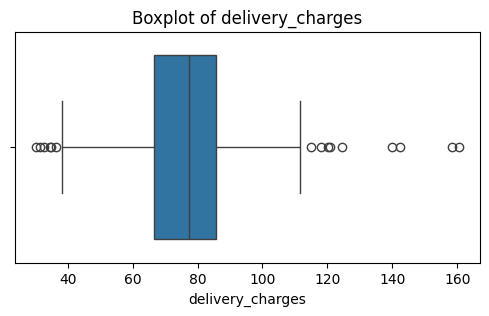

In [32]:
# 可视化 delivery_charges 分布
plt.figure(figsize=(6,3))
sns.boxplot(x=outlier_data['delivery_charges'])
plt.title('Boxplot of delivery_charges')
plt.show()

In [33]:
# 用IQR方法检测异常值
Q1 = outlier_data['delivery_charges'].quantile(0.25)
Q3 = outlier_data['delivery_charges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_rows = outlier_data[(outlier_data['delivery_charges'] < lower_bound) | (outlier_data['delivery_charges'] > upper_bound)]
print(f'检测到的异常行数: {len(outlier_rows)}')


检测到的异常行数: 15


In [34]:

# 移除异常值
outlier_data_cleaned = outlier_data[(outlier_data['delivery_charges'] >= lower_bound) & (outlier_data['delivery_charges'] <= upper_bound)].copy()
print(f'移除异常值后剩余行数: {len(outlier_data_cleaned)}')

移除异常值后剩余行数: 485


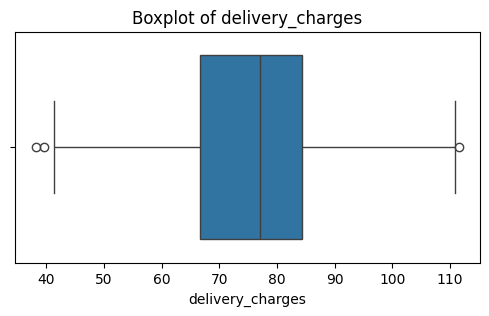

In [35]:
plt.figure(figsize=(6,3))
sns.boxplot(x=outlier_data_cleaned['delivery_charges'])
plt.title('Boxplot of delivery_charges')
plt.show()

In [36]:
outlier_data_cleaned.to_csv('Group_032_outlier_data_solution.csv', index=False)
print("已保存: Group_032_outlier_data_solution.csv")

已保存: Group_032_outlier_data_solution.csv


## 4. 缺失值分析与填补

本节统计各字段缺失情况，并采用合理方法进行填补

In [37]:
# 缺失值分析与填补
print('每列缺失值数量:')
print(missing_data.isnull().sum())

每列缺失值数量:
order_id                          0
customer_id                       0
date                              0
nearest_warehouse                55
shopping_cart                     0
order_price                      15
delivery_charges                 40
customer_lat                      0
customer_long                     0
coupon_discount                   0
order_total                      15
season                            0
is_expedited_delivery             0
distance_to_nearest_warehouse    31
latest_customer_review            0
is_happy_customer                40
dtype: int64


In [38]:
missing_data

,order_id,customer_id,date,nearest_warehouse,shopping_cart,order_price,delivery_charges,customer_lat,customer_long,coupon_discount,order_total,season,is_expedited_delivery,distance_to_nearest_warehouse,latest_customer_review,is_happy_customer
0,ORD247853,ID6221450530,2019-04-09,Bakers,"[('iAssist Line', 1), ('Olivia x460', 2)]",4675.0,80.17,-37.808851,144.983263,10,4287.67,Autumn,True,1.0603,five stars works great! received my order well...,1.0
1,ORD305684,ID0580311159,2019-05-05,Thompson,"[('iStream', 2), ('pearTV', 1), ('Toshika 750'...",13390.0,88.54,-37.804604,144.910296,15,11470.04,Autumn,True,3.3565,very good reliable great photos good battery,NaN
2,ORD477000,ID4957761333,2019-06-20,Thompson,"[('Toshika 750', 1), ('Candle Inferno', 1), ('...",22650.0,71.76,-37.824982,144.928944,25,17059.26,Winter,False,2.1018,amazing and fast great phone and fast performa...,1.0
3,ORD179721,ID0660546015,2019-07-22,Bakers,"[('iStream', 2), ('Olivia x460', 2), ('Toshika...",24010.0,48.09,-37.812235,144.989870,0,24058.09,Winter,False,0.5334,k no era lo k esperaba me decepciona ya van va...,0.0
4,ORD342143,ID4516260665,2019-09-07,NaN,"[('Thunder line', 1), ('Alcon 10', 2), ('Unive...",26980.0,100.85,-37.808103,144.947713,25,20335.85,Spring,True,NaN,five stars works fine,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORD435785,ID3218293521,2019-11-20,Thompson,"[('Toshika 750', 2), ('pearTV', 2), ('Universe...",24710.0,87.29,-37.804300,144.945835,15,21090.79,Spring,True,0.9384,stopped working 2 days after. 30 day warranty ...,0.0
496,ORD089912,ID0331164328,2019-04-14,Nickolson,"[('Olivia x460', 2), ('pearTV', 1), ('Universe...",15810.0,69.92,-37.799879,144.968710,25,11927.42,Autumn,False,2.0847,great! it's a great cellphone for business,NaN
497,ORD345352,ID2188404536,2019-10-31,NaN,"[('Alcon 10', 2), ('Toshika 750', 2), ('pearTV...",35075.0,59.37,-37.812936,144.967579,5,33380.62,Spring,False,NaN,this is suck the device is so weak. i've got t...,0.0
498,ORD486146,ID0154044549,2019-12-30,Nickolson,"[('Lucent 330S', 1), ('Olivia x460', 1)]",2455.0,52.97,-37.820609,144.966868,0,2507.97,Summer,False,0.3255,"horrible phone disappointed in the phone, when...",0.0


In [39]:
# 用情感分析填补缺失的 is_happy_customer
missing_mask = missing_data['is_happy_customer'].isnull()
missing_data.loc[missing_mask, 'is_happy_customer'] = missing_data.loc[missing_mask, 'latest_customer_review'].apply(analyze_sentiment)
print("is_happy_customer 缺失值已用情感分析填补。")

is_happy_customer 缺失值已用情感分析填补。


In [40]:
# 填补缺失的 nearest_warehouse 和 distance_to_nearest_warehouse
missing_mask = missing_data['distance_to_nearest_warehouse'].isnull() | missing_data['nearest_warehouse'].isnull()
missing_data.loc[missing_mask, 'nearest_warehouse'] = missing_data.loc[missing_mask].apply(find_nearest_warehouse, axis=1)
missing_data.loc[missing_mask, 'distance_to_nearest_warehouse'] = missing_data.loc[missing_mask].apply(get_distance, axis=1)
print("缺失的 nearest_warehouse 和 distance_to_nearest_warehouse 已填补。")

缺失的 nearest_warehouse 和 distance_to_nearest_warehouse 已填补。


In [41]:
print('每列缺失值数量:')
print(missing_data.isnull().sum())

每列缺失值数量:
order_id                          0
customer_id                       0
date                              0
nearest_warehouse                 0
shopping_cart                     0
order_price                      15
delivery_charges                 40
customer_lat                      0
customer_long                     0
coupon_discount                   0
order_total                      15
season                            0
is_expedited_delivery             0
distance_to_nearest_warehouse     0
latest_customer_review            0
is_happy_customer                 0
dtype: int64


In [42]:
missing_data[missing_data['order_price'].isnull() | missing_data['order_total'].isnull()][['order_id', 'shopping_cart', 'order_price', 'delivery_charges', 'coupon_discount', 'order_total']]

,order_id,shopping_cart,order_price,delivery_charges,coupon_discount,order_total
83,ORD004263,"[('Alcon 10', 1), ('Candle Inferno', 1), ('Oli...",NaN,75.28,5,NaN
108,ORD208911,"[('iAssist Line', 2), ('Alcon 10', 2), ('Olivi...",NaN,81.25,25,NaN
153,ORD117029,"[('iAssist Line', 1), ('Alcon 10', 1), ('Thund...",NaN,82.69,5,NaN
236,ORD368030,"[('Candle Inferno', 1), ('Lucent 330S', 2), ('...",NaN,97.65,15,NaN
267,ORD082951,"[('Lucent 330S', 2), ('Thunder line', 1), ('iA...",NaN,79.18,5,NaN
275,ORD140877,"[('Alcon 10', 1), ('pearTV', 1)]",NaN,65.00,0,NaN
291,ORD129509,"[('Olivia x460', 1), ('pearTV', 2), ('Toshika ...",NaN,63.51,15,NaN
292,ORD415208,"[('Thunder line', 1), ('Universe Note', 1), ('...",NaN,76.10,15,NaN
293,ORD439337,"[('Candle Inferno', 2), ('Universe Note', 2), ...",NaN,92.58,5,NaN
325,ORD253751,"[('Olivia x460', 1), ('iStream', 1)]",NaN,70.18,15,NaN


In [43]:
# 步骤1：将 shopping_cart 解析为规范化字符串，便于匹配
from ast import literal_eval

def normalize_cart(cart):
    try:
        items = literal_eval(str(cart))
        return str(sorted(items))
    except:
        return str(cart)

missing_data['cart_key'] = missing_data['shopping_cart'].apply(normalize_cart)
print(missing_data[['shopping_cart', 'cart_key']].head())


                                       shopping_cart  \
0          [('iAssist Line', 1), ('Olivia x460', 2)]   
1  [('iStream', 2), ('pearTV', 1), ('Toshika 750'...   
2  [('Toshika 750', 1), ('Candle Inferno', 1), ('...   
3  [('iStream', 2), ('Olivia x460', 2), ('Toshika...   
4  [('Thunder line', 1), ('Alcon 10', 2), ('Unive...   

                                            cart_key  
0          [('Olivia x460', 2), ('iAssist Line', 1)]  
1  [('Lucent 330S', 2), ('Toshika 750', 1), ('iSt...  
2  [('Alcon 10', 2), ('Candle Inferno', 1), ('Tos...  
3  [('Olivia x460', 2), ('Toshika 750', 2), ('iSt...  
4  [('Alcon 10', 2), ('Thunder line', 1), ('Unive...  


In [44]:

# 步骤2：统计每种 cart_key 已有的 order_price 均值
cart_price_map = missing_data.loc[missing_data['order_price'].notnull()].groupby('cart_key')['order_price'].mean().to_dict()
print('cart_key 到 order_price 均值映射示例:')
for k, v in list(cart_price_map.items())[:5]:
    print(k, '->', v)

cart_key 到 order_price 均值映射示例:
[('Alcon 10', 1), ('Candle Inferno', 1), ('Lucent 330S', 2), ('Thunder line', 1)] -> 14020.0
[('Alcon 10', 1), ('Candle Inferno', 1), ('Lucent 330S', 2), ('pearTV', 2)] -> 24460.0
[('Alcon 10', 1), ('Candle Inferno', 1), ('Thunder line', 2), ('pearTV', 2)] -> 26360.0
[('Alcon 10', 1), ('Candle Inferno', 1), ('Toshika 750', 2), ('iAssist Line', 2)] -> 22470.0
[('Alcon 10', 1), ('Candle Inferno', 1), ('Toshika 750', 2), ('iStream', 1)] -> 18170.0


In [45]:

# 步骤3：用映射填补缺失的 order_price
mask = missing_data['order_price'].isnull()
missing_data.loc[mask, 'order_price'] = missing_data.loc[mask, 'cart_key'].map(cart_price_map)


# 基于填补的 order_price 补全 order_total
mask_total = missing_data['order_total'].isnull()
missing_data.loc[mask_total, 'order_total'] = missing_data.loc[mask_total].apply(get_order_total, axis=1)
print("order_price 和 order_total 缺失值已填补。")


print('填补后 order_price 剩余缺失:', missing_data['order_price'].isnull().sum())

# 步骤4：删除辅助列
missing_data.drop(columns=['cart_key'], inplace=True)

order_price 和 order_total 缺失值已填补。
填补后 order_price 剩余缺失: 9


In [46]:
missing_data[missing_data['order_price'].isnull() | missing_data['order_total'].isnull()][['order_id', 'shopping_cart', 'order_price', 'delivery_charges', 'coupon_discount', 'order_total']]

,order_id,shopping_cart,order_price,delivery_charges,coupon_discount,order_total
83,ORD004263,"[('Alcon 10', 1), ('Candle Inferno', 1), ('Oli...",NaN,75.28,5,NaN
153,ORD117029,"[('iAssist Line', 1), ('Alcon 10', 1), ('Thund...",NaN,82.69,5,NaN
267,ORD082951,"[('Lucent 330S', 2), ('Thunder line', 1), ('iA...",NaN,79.18,5,NaN
275,ORD140877,"[('Alcon 10', 1), ('pearTV', 1)]",NaN,65.00,0,NaN
291,ORD129509,"[('Olivia x460', 1), ('pearTV', 2), ('Toshika ...",NaN,63.51,15,NaN
292,ORD415208,"[('Thunder line', 1), ('Universe Note', 1), ('...",NaN,76.10,15,NaN
293,ORD439337,"[('Candle Inferno', 2), ('Universe Note', 2), ...",NaN,92.58,5,NaN
338,ORD480498,"[('iStream', 1), ('Toshika 750', 1), ('Thunder...",NaN,75.66,25,NaN
476,ORD222050,"[('Toshika 750', 2), ('iAssist Line', 2), ('Ol...",NaN,66.68,25,NaN


In [47]:
# 用全体 order_price 的中位数填补剩余缺失
median_price = missing_data['order_price'].median()
missing_data['order_price'].fillna(median_price, inplace=True)

# 再次填补 order_total
mask_total = missing_data['order_total'].isnull()
missing_data.loc[mask_total, 'order_total'] = missing_data.loc[mask_total].apply(get_order_total, axis=1)

print('最终填补后 order_price 剩余缺失:', missing_data['order_price'].isnull().sum())
print('最终填补后 order_total 剩余缺失:', missing_data['order_total'].isnull().sum())

最终填补后 order_price 剩余缺失: 0
最终填补后 order_total 剩余缺失: 0


In [48]:
print('每列缺失值数量:')
print(missing_data.isnull().sum())

每列缺失值数量:
order_id                          0
customer_id                       0
date                              0
nearest_warehouse                 0
shopping_cart                     0
order_price                       0
delivery_charges                 40
customer_lat                      0
customer_long                     0
coupon_discount                   0
order_total                       0
season                            0
is_expedited_delivery             0
distance_to_nearest_warehouse     0
latest_customer_review            0
is_happy_customer                 0
dtype: int64



### 1. **dirty_data（Group<group_id>_dirty_data.csv）**
- 每一行最多只有一个异常（anomaly）。
- 每个异常只有唯一的修正方法（one and only one possible fix）。
- 你需要**检测并修正所有异常**，包括格式错误、逻辑错误、拼写错误、越界等。

---

### 2. **outlier_data（Group<group_id>_outlier_data.csv）**
- **没有其他数据异常**，只有**outlier（离群值）**。
- 只需要**检测并移除delivery_charges字段的异常值**，不用处理其他字段。

---

### 3. **missing_data（Group<group_id>_missing_data.csv）**
- **只有缺失值相关的异常**（coverage data anomalies），没有其他类型的数据异常。
- 只需要**填补缺失值**，不用处理其他字段的错误。

---

**总结：**
- dirty_data：每行最多一个异常，且只有唯一修正方法，要全部修正。
- outlier_data：只处理delivery_charges的离群值，其他字段不用管。
- missing_data：只处理缺失值，其他字段不用管。


In [49]:
# 按季节分别训练线性回归模型，特征包括距离、加急、客户满意度
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 特征工程：将布尔型转为0/1
for df in [dirty_data_cleaned, outlier_data_cleaned, missing_data]:
    df['expedited'] = df['is_expedited_delivery'].astype(int)
    df['happy'] = df['is_happy_customer'].astype(int)

# 合并训练集
total_df = pd.concat([dirty_data_cleaned, outlier_data_cleaned, missing_data], ignore_index=True)

# 只保留关键特征和无缺失的训练样本
features = ['distance_to_nearest_warehouse', 'expedited', 'happy']
target = 'delivery_charges'

# 按季节建模
season_models = {}
season_r2 = {}
for season in total_df['season'].dropna().unique():
    df_season = total_df[(total_df['season'] == season) & total_df[features + [target]].notnull().all(axis=1)]
    if len(df_season) < 10:
        continue  # 样本太少不建模
    X = df_season[features]
    y = df_season[target]
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    season_models[season] = model
    season_r2[season] = r2
    print(f"Season: {season}, R2: {r2:.4f}, n={len(df_season)}")


Season: Summer, R2: 0.7107, n=384
Season: Spring, R2: 0.7568, n=343
Season: Winter, R2: 0.6845, n=377
Season: Autumn, R2: 0.7512, n=341
Season: Spring, R2: 0.7568, n=343
Season: Winter, R2: 0.6845, n=377
Season: Autumn, R2: 0.7512, n=341


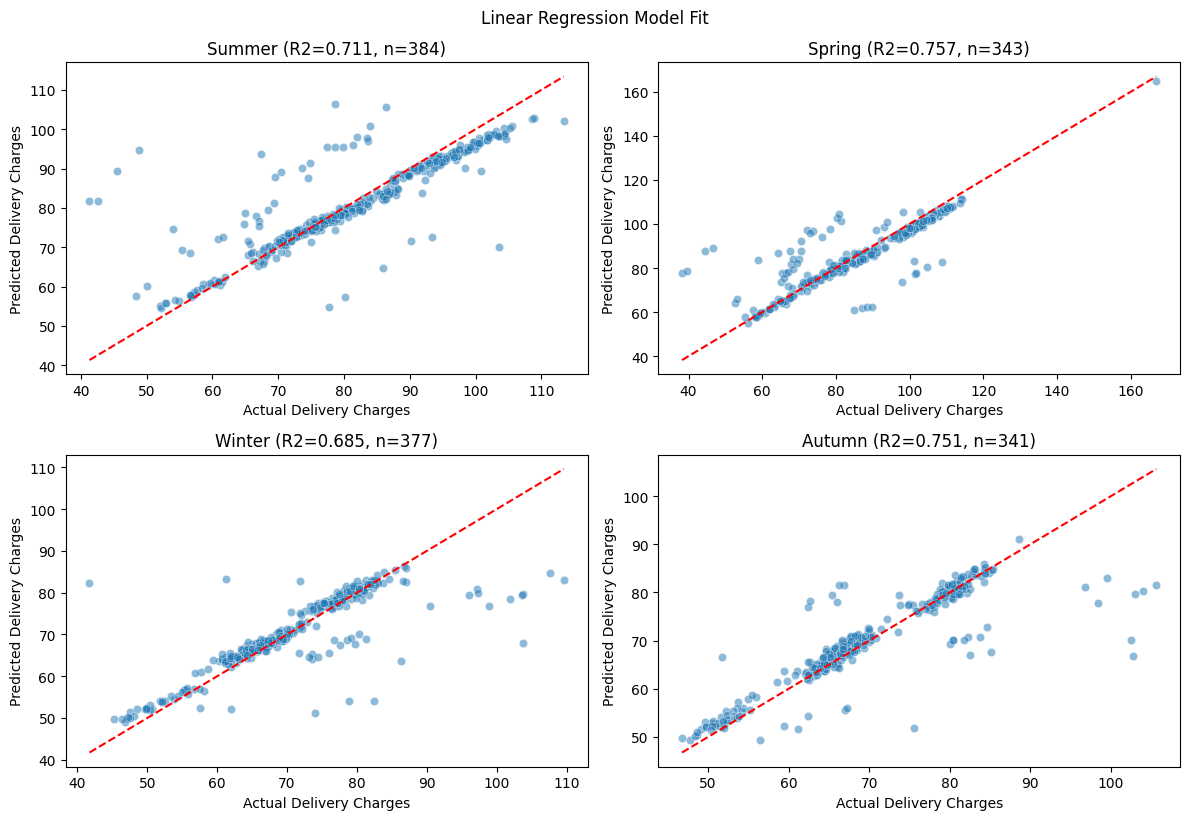

In [50]:
# 可视化每个季节的拟合效果（真实值 vs 预测值）
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
for i, (season, model) in enumerate(season_models.items()):
    df_season = total_df[(total_df['season'] == season) & total_df[features + [target]].notnull().all(axis=1)]
    X = df_season[features]
    y_true = df_season[target]
    y_pred = model.predict(X)
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Delivery Charges')
    plt.ylabel('Predicted Delivery Charges')
    plt.title(f'{season} (R2={season_r2[season]:.3f}, n={len(df_season)})')
plt.tight_layout()
plt.suptitle('Linear Regression Model Fit', y=1.02)
plt.show()

In [51]:
# 用分季节模型预测 missing_data 中缺失的 delivery_charges
for season, model in season_models.items():
    mask = (missing_data['season'] == season) & missing_data['delivery_charges'].isnull() \
           & missing_data[features].notnull().all(axis=1)
    if mask.sum() > 0:
        X_pred = missing_data.loc[mask, features]
        pred_delivery = model.predict(X_pred)
        missing_data.loc[mask, 'delivery_charges'] = pred_delivery

print('分季节线性回归模型已训练并用于填补 missing_data 的 delivery_charges。')
print('missing_data 剩余 delivery_charges 缺失:', missing_data['delivery_charges'].isnull().sum())

分季节线性回归模型已训练并用于填补 missing_data 的 delivery_charges。
missing_data 剩余 delivery_charges 缺失: 0


In [52]:
missing_data_filled = missing_data.copy()
missing_data_filled.to_csv('Group_032_outlier_data_solution.csv')